In [11]:
#2021.08.18. WED
#Team_밥믈리에

#00. 패키지 호출
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA
import warnings 

#00-1. warning message ignore 
warnings.filterwarnings(action='ignore')


In [12]:
#01. 데이터셋 호출 및 전처리하기. 
#(1) 데이터셋 불러오기
cultivar_dataset = pd.read_excel('../data/nlp/cultivar_MF.xlsx')

#(2) 데이터셋의 cultivar 컬럼 인덱스로 설정하기. 
cultivar_dataset.set_index('cultivar', inplace=True)

#(3) 결과 확인하기. 
cultivar_dataset

,고소하다,고슬하다,누룽지,눅눅하다,달다,매끈하다,부드럽다,짜다,쫀득하다,찰지다,통통하다,푸석하다
cultivar,,,,,,,,,,,,
count_고시히카리,0.385135,0.128378,0.000000,0.009009,0.231982,0.013514,0.051802,0.092342,0.299550,1.000000,0.137387,0.112613
count_골드퀸,1.000000,0.000000,0.257642,0.000000,0.000000,0.000000,0.000000,0.008734,0.000000,0.087336,0.000000,0.000000
count_삼광,0.512195,0.048780,0.000000,0.000000,0.182927,0.020325,0.000000,0.048780,0.182927,1.000000,0.008130,0.121951
count_신동진,0.470687,0.097152,0.000000,0.018425,0.169179,0.470687,0.053601,0.157454,0.167504,1.000000,0.207705,0.246231
count_영호진미,0.291845,0.098712,0.000000,0.017167,0.047210,0.008584,0.068670,0.124464,0.197425,1.000000,0.000000,0.339056
count_오대,0.445545,0.069307,0.000000,0.024752,0.193069,0.099010,0.034653,0.113861,0.178218,1.000000,0.113861,0.282178
count_일품,0.588235,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.029412,0.000000,1.000000,0.000000,0.000000
count_진상,0.106383,0.000000,0.000000,0.000000,0.127660,0.000000,0.000000,0.000000,0.170213,1.000000,0.000000,0.000000
count_참드림,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000


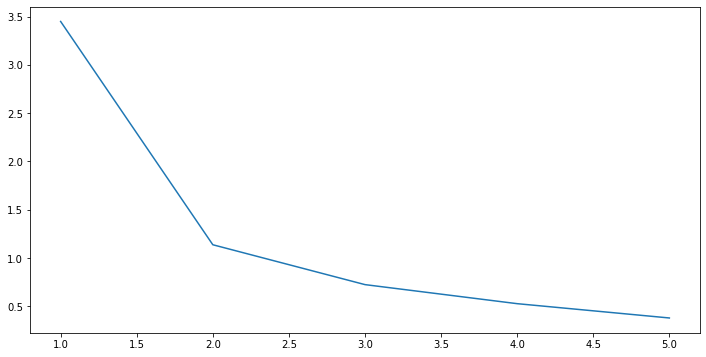

In [13]:
#02-1. k-means 모델 적용 전, 최적 k 값 파악을 위한 엘보우포인트 파악하기.
#(1) k 값에 따른 inertia(관성) 값 수집하기. 
inertia_list = []
for k in range(1,5+1) :
    kmeans_model = KMeans(n_clusters=k, random_state=2021)
    kmeans_model.fit(cultivar_dataset)
    inertia = kmeans_model.inertia_
    inertia_list.append(inertia)

#(2) 시각화하기.
plt.figure(figsize=(12,6))
plt.plot(range(1,5+1), inertia_list)
plt.show()

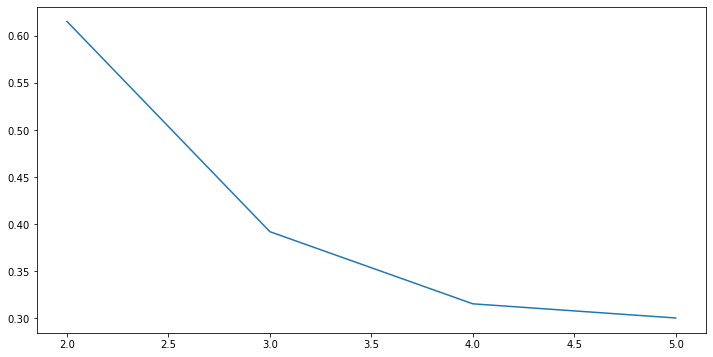

In [14]:
#02-2. k-means 모델 적용 전, 최적 k값 파악을 위한 실루엣계수 파악하기. 
#(1) k 값에 따른 silhouette_score 값 수집하기. 
silh_score_list = []
for k in [2, 3, 4, 5] :
    kmeans_model = KMeans(n_clusters=k, random_state=2021)
    silh_score = silhouette_score(cultivar_dataset.iloc[:,:12], kmeans_model.fit_predict(cultivar_dataset))
    silh_score_list.append(silh_score)

#(2) 시각화하기. 
plt.figure(figsize=(12,6))
plt.plot(range(2,5+1), silh_score_list)
plt.show()

In [15]:
#MEMO. 최적 k값은 2로 결정함. 

In [16]:
#03. k-means 모델로 군집화하기. 
#(1) k-means 모델 객체 정의하기. 
kmeans_model = KMeans(n_clusters=2, random_state=2021)

#(2) 데이터셋에 군집 번호 컬럼 추가하기. 
cultivar_dataset['cluster_num'] = kmeans_model.fit_predict(cultivar_dataset.iloc[:,:12])

#(4) 행 별 실루엣 계수 컬럼 추가하기. 
#cultivar_dataset['silhouette_coef'] = silhouette_samples(cultivar_dataset.iloc[:,:12], cultivar_dataset['cluster_num'])

#(5) 처리 결과 확인하기. 
cultivar_dataset

,고소하다,고슬하다,누룽지,눅눅하다,달다,매끈하다,부드럽다,짜다,쫀득하다,찰지다,통통하다,푸석하다,cluster_num
cultivar,,,,,,,,,,,,,
count_고시히카리,0.385135,0.128378,0.000000,0.009009,0.231982,0.013514,0.051802,0.092342,0.299550,1.000000,0.137387,0.112613,0
count_골드퀸,1.000000,0.000000,0.257642,0.000000,0.000000,0.000000,0.000000,0.008734,0.000000,0.087336,0.000000,0.000000,1
count_삼광,0.512195,0.048780,0.000000,0.000000,0.182927,0.020325,0.000000,0.048780,0.182927,1.000000,0.008130,0.121951,0
count_신동진,0.470687,0.097152,0.000000,0.018425,0.169179,0.470687,0.053601,0.157454,0.167504,1.000000,0.207705,0.246231,0
count_영호진미,0.291845,0.098712,0.000000,0.017167,0.047210,0.008584,0.068670,0.124464,0.197425,1.000000,0.000000,0.339056,0
count_오대,0.445545,0.069307,0.000000,0.024752,0.193069,0.099010,0.034653,0.113861,0.178218,1.000000,0.113861,0.282178,0
count_일품,0.588235,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.029412,0.000000,1.000000,0.000000,0.000000,0
count_진상,0.106383,0.000000,0.000000,0.000000,0.127660,0.000000,0.000000,0.000000,0.170213,1.000000,0.000000,0.000000,0
count_참드림,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0


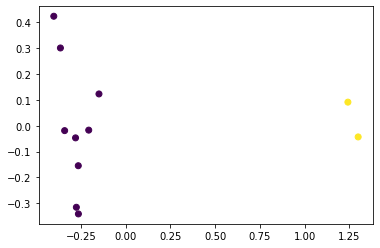

In [17]:
#04. 군집 시각화하기. 
#(1) 주성분 분석을 통해 2차원으로 축소하기. 
pca = PCA(n_components=2, random_state=2021)
cultivar_dataset_pca = pca.fit_transform(cultivar_dataset)
cultivar_dataset_pca = pd.DataFrame(cultivar_dataset_pca, columns=['PC1','PC2'])
cultivar_dataset_pca['cluster_num'] = kmeans_model.fit_predict(cultivar_dataset_pca)

#(2) PCA 처리값을 기반으로 시각화하기. 
plt.scatter(x=cultivar_dataset_pca['PC1'], y=cultivar_dataset_pca['PC2'], c=cultivar_dataset_pca['cluster_num'])
plt.show()